In [1]:
# Import Libraries

import pandas as pd
import numpy as np


In [2]:
# Load cleaned data

data = pd.read_csv(r'C:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\Data Cleaning&EDA\cleaned_data.csv')

data.head(2)

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69


**Features check for Data Leakage**

Features unlikely to cause leakage (Safe to use as features):

a. Product_ID – OK -- identifier.

b. Category – OK -- static product info.

c. Price – OK -- known at time of sale and a key driver.

d. Date – OK -- can derive temporal patterns like seasonality.

e. Season – OK --derived from date; not a leakage risk.

f. Market_Trend_Index – OK -- assumed to be external and known at prediction time.

g. Consumer_Confidence_Index – OK -- also assumed to be known at prediction time.

h. Product_Specification_1 - OK -- product metadata and static.

i. Product_Specification_2 – OK -- product metadata and static

**Potential Leakage Column:**

i. Competitor_Activity_Score - LEAKY (If the score is computed on actual market outcomes or competitor performance after the fact, and not from publicly known information before the sale)

ii. Competitor_Activity_Score - OK (If it is based on historical or real-time publicly available data at the time of the sale).

**Recommendation:**

a. Lag Competitor_Activity_Score and encode categorical variables


In [3]:
# Shape of the data
data.shape

(136193, 11)

                     Feature  MI_Score
2                      Price  4.927765
0                 Product_ID  2.887902
3                     Season  0.345399
4         Market_Trend_Index  0.010257
7    Product_Specification_1  0.001436
1                   Category  0.000000
5  Competitor_Activity_Score  0.000000
6  Consumer_Confidence_Index  0.000000
8    Product_Specification_2  0.000000


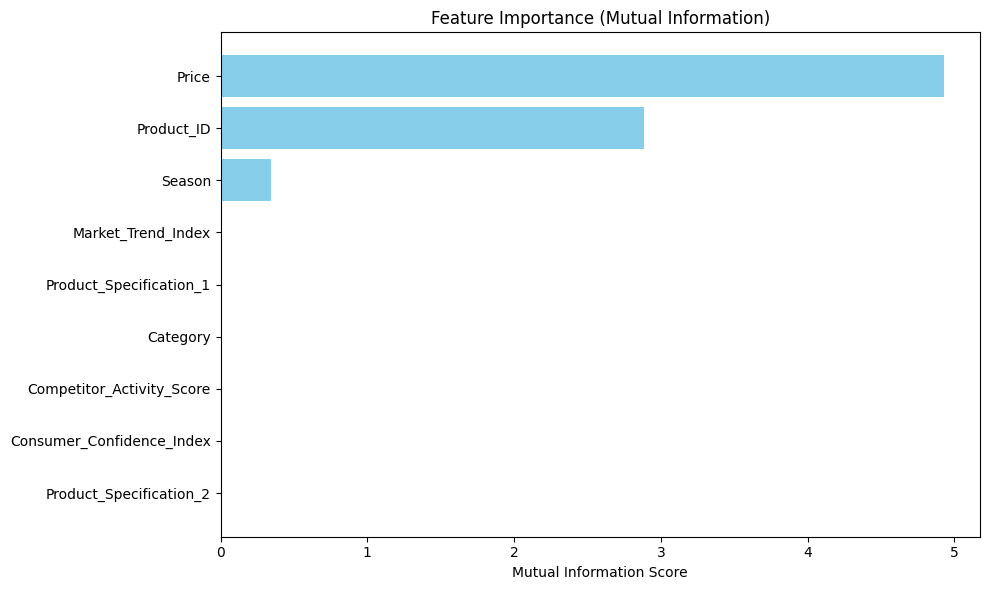

In [4]:
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

# Copy original data
mi_data = data

# Define the feature and target matrix
X = mi_data.drop(columns=['Sales_Volume', 'Date'])
target = mi_data['Sales_Volume']

# Convert string/object columns to category type
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# Compute mutual information scores
mi_scores = mutual_info_regression(X, target, discrete_features=True, random_state=42)

# Create DataFrame of feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# Display the result
print(feature_importance)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['MI_Score'], color='skyblue')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance (Mutual Information)')
plt.gca().invert_yaxis()  # Most important on top
plt.tight_layout()
plt.show()

**Temporal Analysis**


C:\Users\USER\AppData\Local\Temp\ipykernel_21060\492660009.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['Sales_Volume']


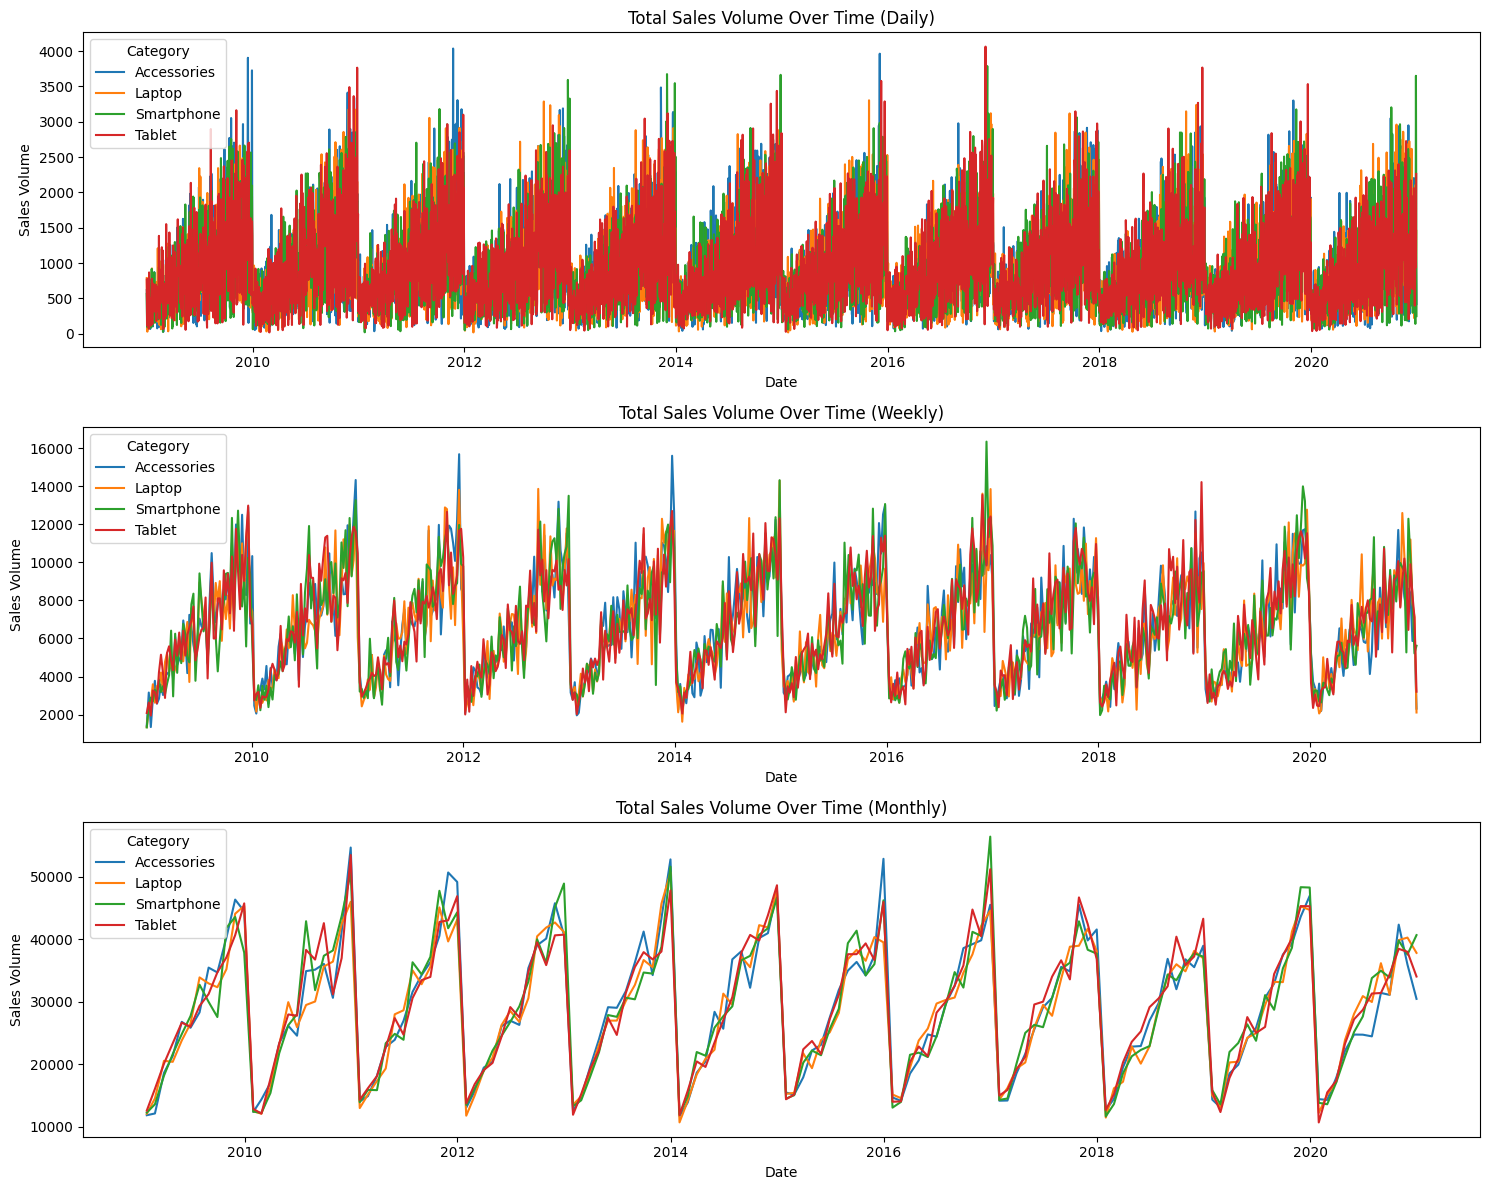

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Date' is datetime
data['Date'] = pd.to_datetime(data['Date'])

# 1. DAILY data
daily_data = (data.groupby(['Date', 'Category'])['Sales_Volume'].sum().reset_index())

# 2. WEEKLY data
weekly_data = (data.set_index('Date').groupby('Category').resample('W')['Sales_Volume'].sum().reset_index())

# 3. MONTHLY data
monthly_data = (data.set_index('Date').groupby('Category').resample('M')['Sales_Volume'].sum().reset_index())

# Visualise the data

fig, ax = plt.subplots(3, 1, figsize=(15, 12))

# Daily
sns.lineplot(data=daily_data, x='Date', y='Sales_Volume', hue='Category', ax=ax[0])
ax[0].set_title('Total Sales Volume Over Time (Daily)')
ax[0].set_ylabel('Sales Volume')

# Weekly
sns.lineplot(data=weekly_data, x='Date', y='Sales_Volume', hue='Category', ax=ax[1])
ax[1].set_title('Total Sales Volume Over Time (Weekly)')
ax[1].set_ylabel('Sales Volume')

# Monthly
sns.lineplot(data=monthly_data, x='Date', y='Sales_Volume', hue='Category', ax=ax[2])
ax[2].set_title('Total Sales Volume Over Time (Monthly)')
ax[2].set_ylabel('Sales Volume')

plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_21060\1470792819.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_based_data = time_based_data.set_index('Date').resample('M').sum().reset_index()
C:\Users\USER\AppData\Local\Temp\ipykernel_21060\1470792819.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_based_data = time_based_data.set_index('Date').resample('M').sum().reset_index()
C:\Users\USER\AppData\Local\Temp\ipykernel_21060\1470792819.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_based_data = time_based_data.set_index('Date').resample('M').sum().reset_index()
C:\Users\USER\AppData\Local\Temp\ipykernel_21060\1470792819.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_based_data = time_based_data.set_index('Date').resample('M').sum(

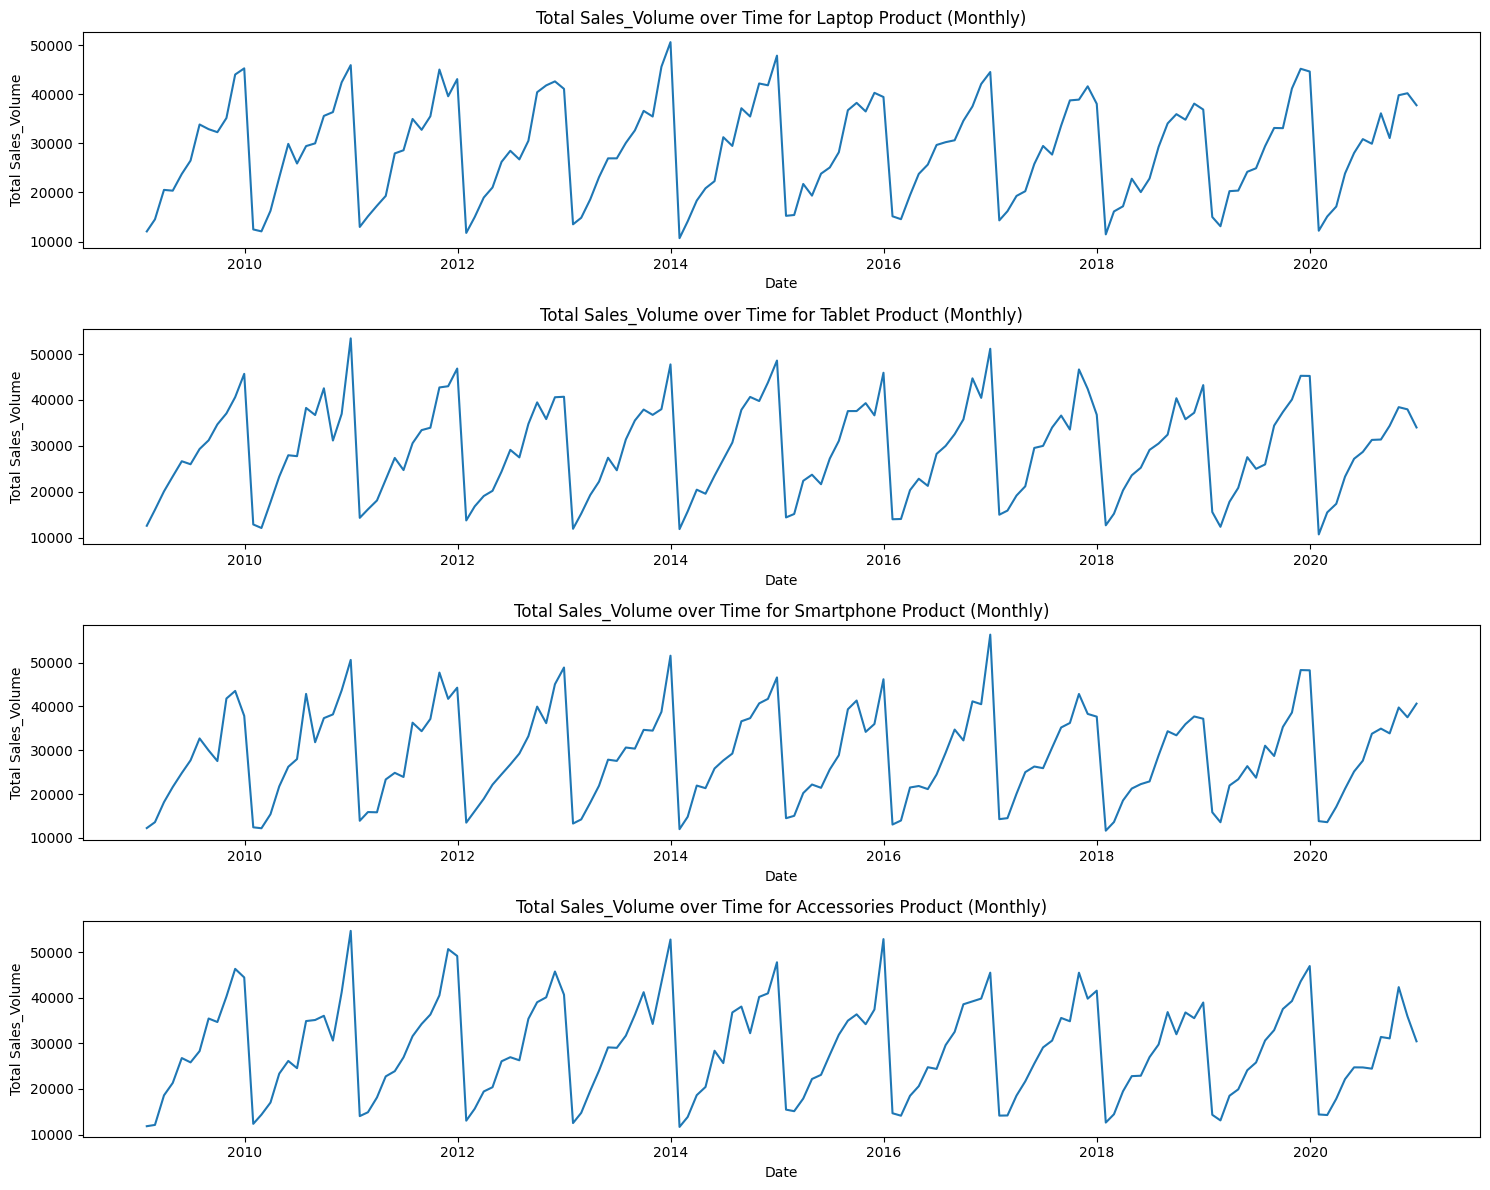

In [11]:
products = data['Category'].unique()

fig, ax = plt.subplots(len(products), figsize=(15, 12))

for i, product in enumerate(products):
    time_based_data = data[data['Category'] == product]

    time_based_data = time_based_data.groupby('Date').agg({'Sales_Volume': 'sum'}).reset_index()

    time_based_data = time_based_data.set_index('Date').resample('M').sum().reset_index()

    # Quantity Sold over Time
    sns.lineplot(data=time_based_data, x='Date', y='Sales_Volume', ax=ax[i])
    ax[i].set_title(f'Total Sales_Volume over Time for {product} Product (Monthly)')
    ax[i].set_ylabel('Total Sales_Volume')

plt.tight_layout()
plt.show()


**Stationarity Check**

Check stationarity of time series data to ascertain the statistical properties (mean, variance, and autocorrelation) remain constant over time.

In [17]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# ADF test function
def adf_test(series):
    result = adfuller(series)
    dataoutput = pd.Series(result[0:4], index=[
        'Test Statistic',
        'p-value',
        '# lags used',
        'number of observations used'
    ])
    
    for key, value in result[4].items():
        dataoutput[f'critical value ({key})'] = value
        
    return dataoutput

# Stationarity test
stationarity_test = dict()

# Loop through each unique category in the 'Category' column
for cat in data['Category'].unique():
    category_data = data[data['Category'] == cat]
    stationarity_test[cat] = adf_test(category_data['Sales_Volume'])

# Display results as DataFrame
pd.DataFrame(stationarity_test)


,Laptop,Tablet,Smartphone,Accessories
Test Statistic,-6.155656e+00,-6.383202e+00,-5.778979e+00,-6.043618e+00
p-value,7.379600e-08,2.196351e-08,5.179050e-07,1.327845e-07
# lags used,3.600000e+01,3.200000e+01,4.400000e+01,3.600000e+01
number of observations used,3.376500e+04,3.433700e+04,3.393500e+04,3.400400e+04
critical value (1%),-3.430544e+00,-3.430540e+00,-3.430543e+00,-3.430542e+00
critical value (5%),-2.861626e+00,-2.861624e+00,-2.861625e+00,-2.861625e+00
critical value (10%),-2.566816e+00,-2.566815e+00,-2.566815e+00,-2.566815e+00


**ADF Test Result**

a. Product categories tested with ADF test are stationary (p-value < 0.05 for all). 

b. The Test Statistic is less than all critical values (1%, 5%, 10%) for all products.

c. Since all series are stationary, no differencing (d=0) is required when using models like ARIMA or SARIMAX.

d. This also simplifies modeling with Prophet, as stationary inputs typically improve forecast stability (especially for regressors).

**Conclusion:** The result of Augmented Dickey-Fuller test shows the categorical dataset is stationary. So, d = 0 (no differencing needed).

**Plot ACF (Auto-correlation Function) and PACF (Partial Auto-correlation Function)**

The plot helps to get AR (Auto Regressive) and MA (Moving Average) values. These are two parameters needed to build ARIMA model

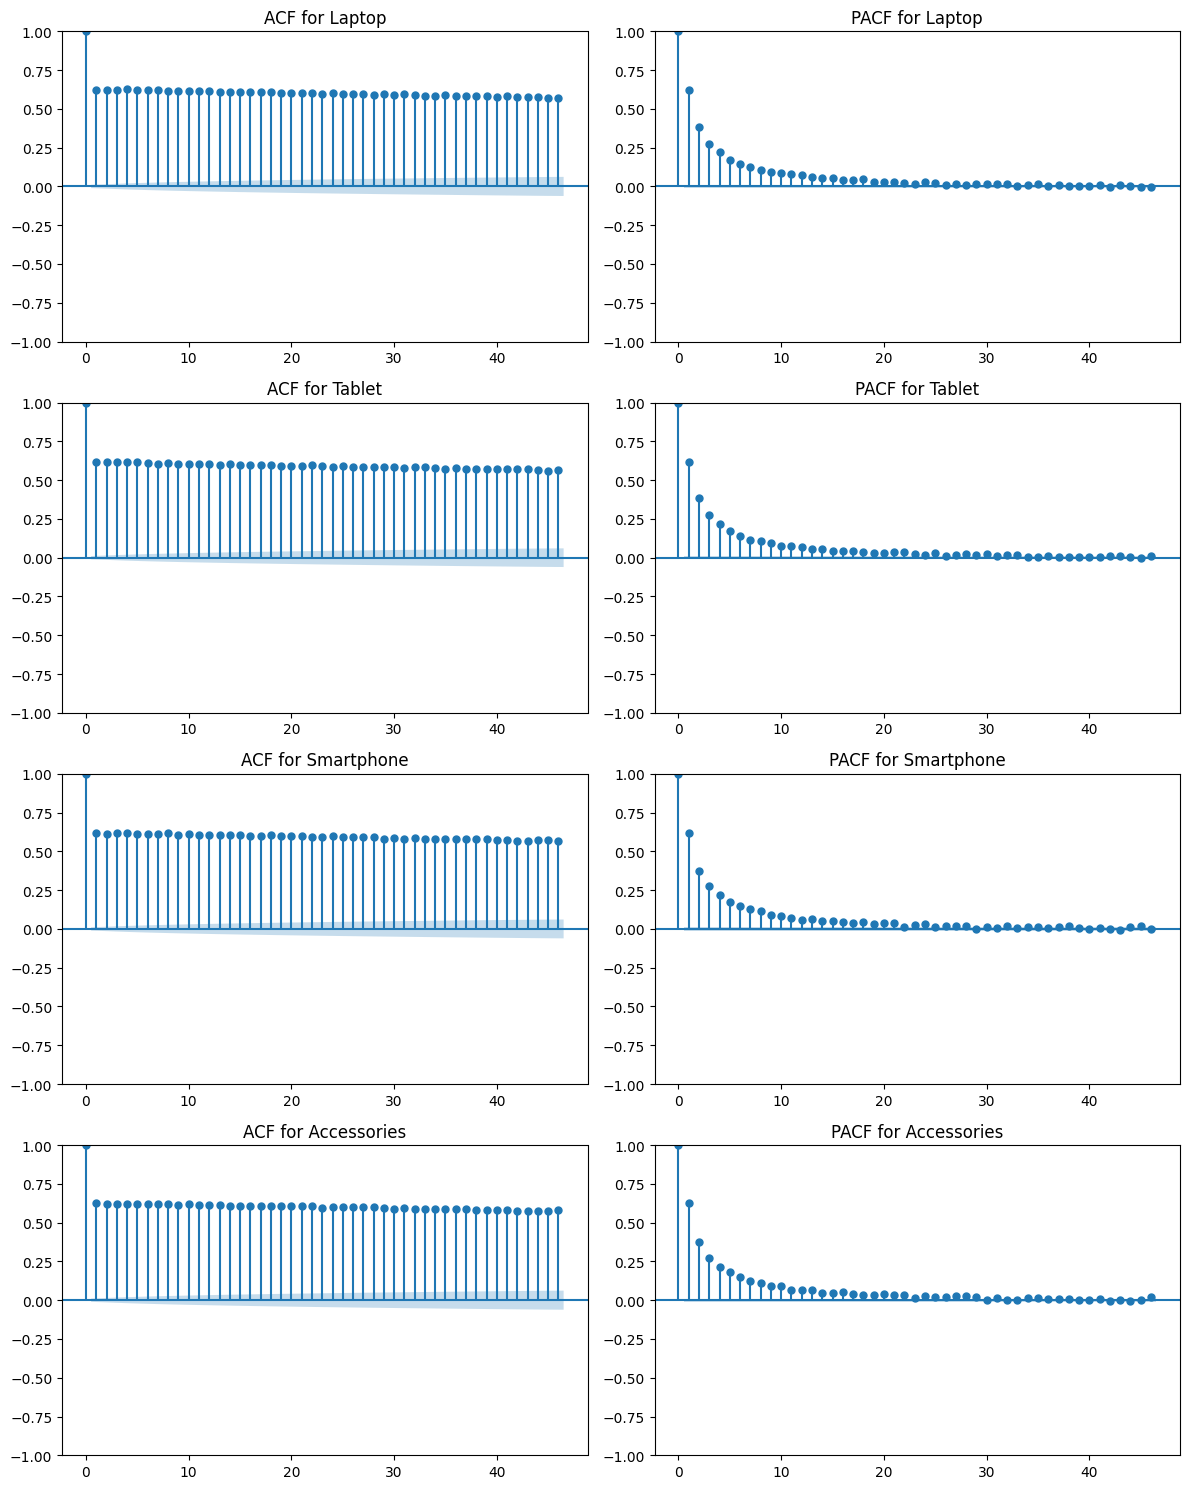

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for each category
fig, ax = plt.subplots(len(data['Category'].unique()), 2, figsize=(12, 15))

for i, cat in enumerate(data['Category'].unique()):
    category_data = data[data['Category'] == cat]

    # ACF plot
    plot_acf(category_data['Sales_Volume'], ax=ax[i][0], title=f'ACF for {cat}')

    # PACF plot
    plot_pacf(category_data['Sales_Volume'], ax=ax[i][1], title=f'PACF for {cat}')

plt.tight_layout()
plt.show()


For all 4 categories (Laptop, Tablet, Smartphone, Accessories):

ACF Plots: ACF does not cut off sharply but decays slowly. This indicates a moving average component might be needed. The decay is slow, but still suggests MA term q = 1 as a starting point.

This suggests you should probably difference the data first (i.e., d=1 in ARIMA).

PACF Plots: Cuts off sharply after lag 1. This means the first lag is significant and the rest drop off. This is a classic indication of AR (1). SO p = 1.

ARIMA(order=(1, 0, 1))

**Data Preparation**

Aggregating Daily dataset to Monthly dataset

In [19]:
# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Select required columns
sales_by_month_category = data[['Date', 'Category', 'Sales_Volume']].copy()

# Convert Date to monthly period
sales_by_month_category['Date'] = sales_by_month_category['Date'].dt.to_period('M')

# Group by month and category
sales_by_month_category = (
    sales_by_month_category
    .groupby(['Date', 'Category'], as_index=False)['Sales_Volume']
    .sum()
)

# Convert Period back to Timestamp (month start)
sales_by_month_category['Date'] = sales_by_month_category['Date'].dt.to_timestamp()

# Set Date as index (optional, but useful for time series)
sales_by_month_category.set_index('Date', inplace=True)

sales_by_month_category.head()


,Category,Sales_Volume
Date,,
2009-01-01,Accessories,11830
2009-01-01,Laptop,12062
2009-01-01,Smartphone,12239
2009-01-01,Tablet,12564
2009-02-01,Accessories,12111


**Endogenous variable**

Sales_Volume is the only appropriate target variable (y) as it represents customer actual demand, and aligns with the project objectives of reducing stock discrepancies, improving inventory planning, ensuring product availability, preventing financial loss from under/over-stocking and increasing  customer satisfaction. 

**Feature Engineering**

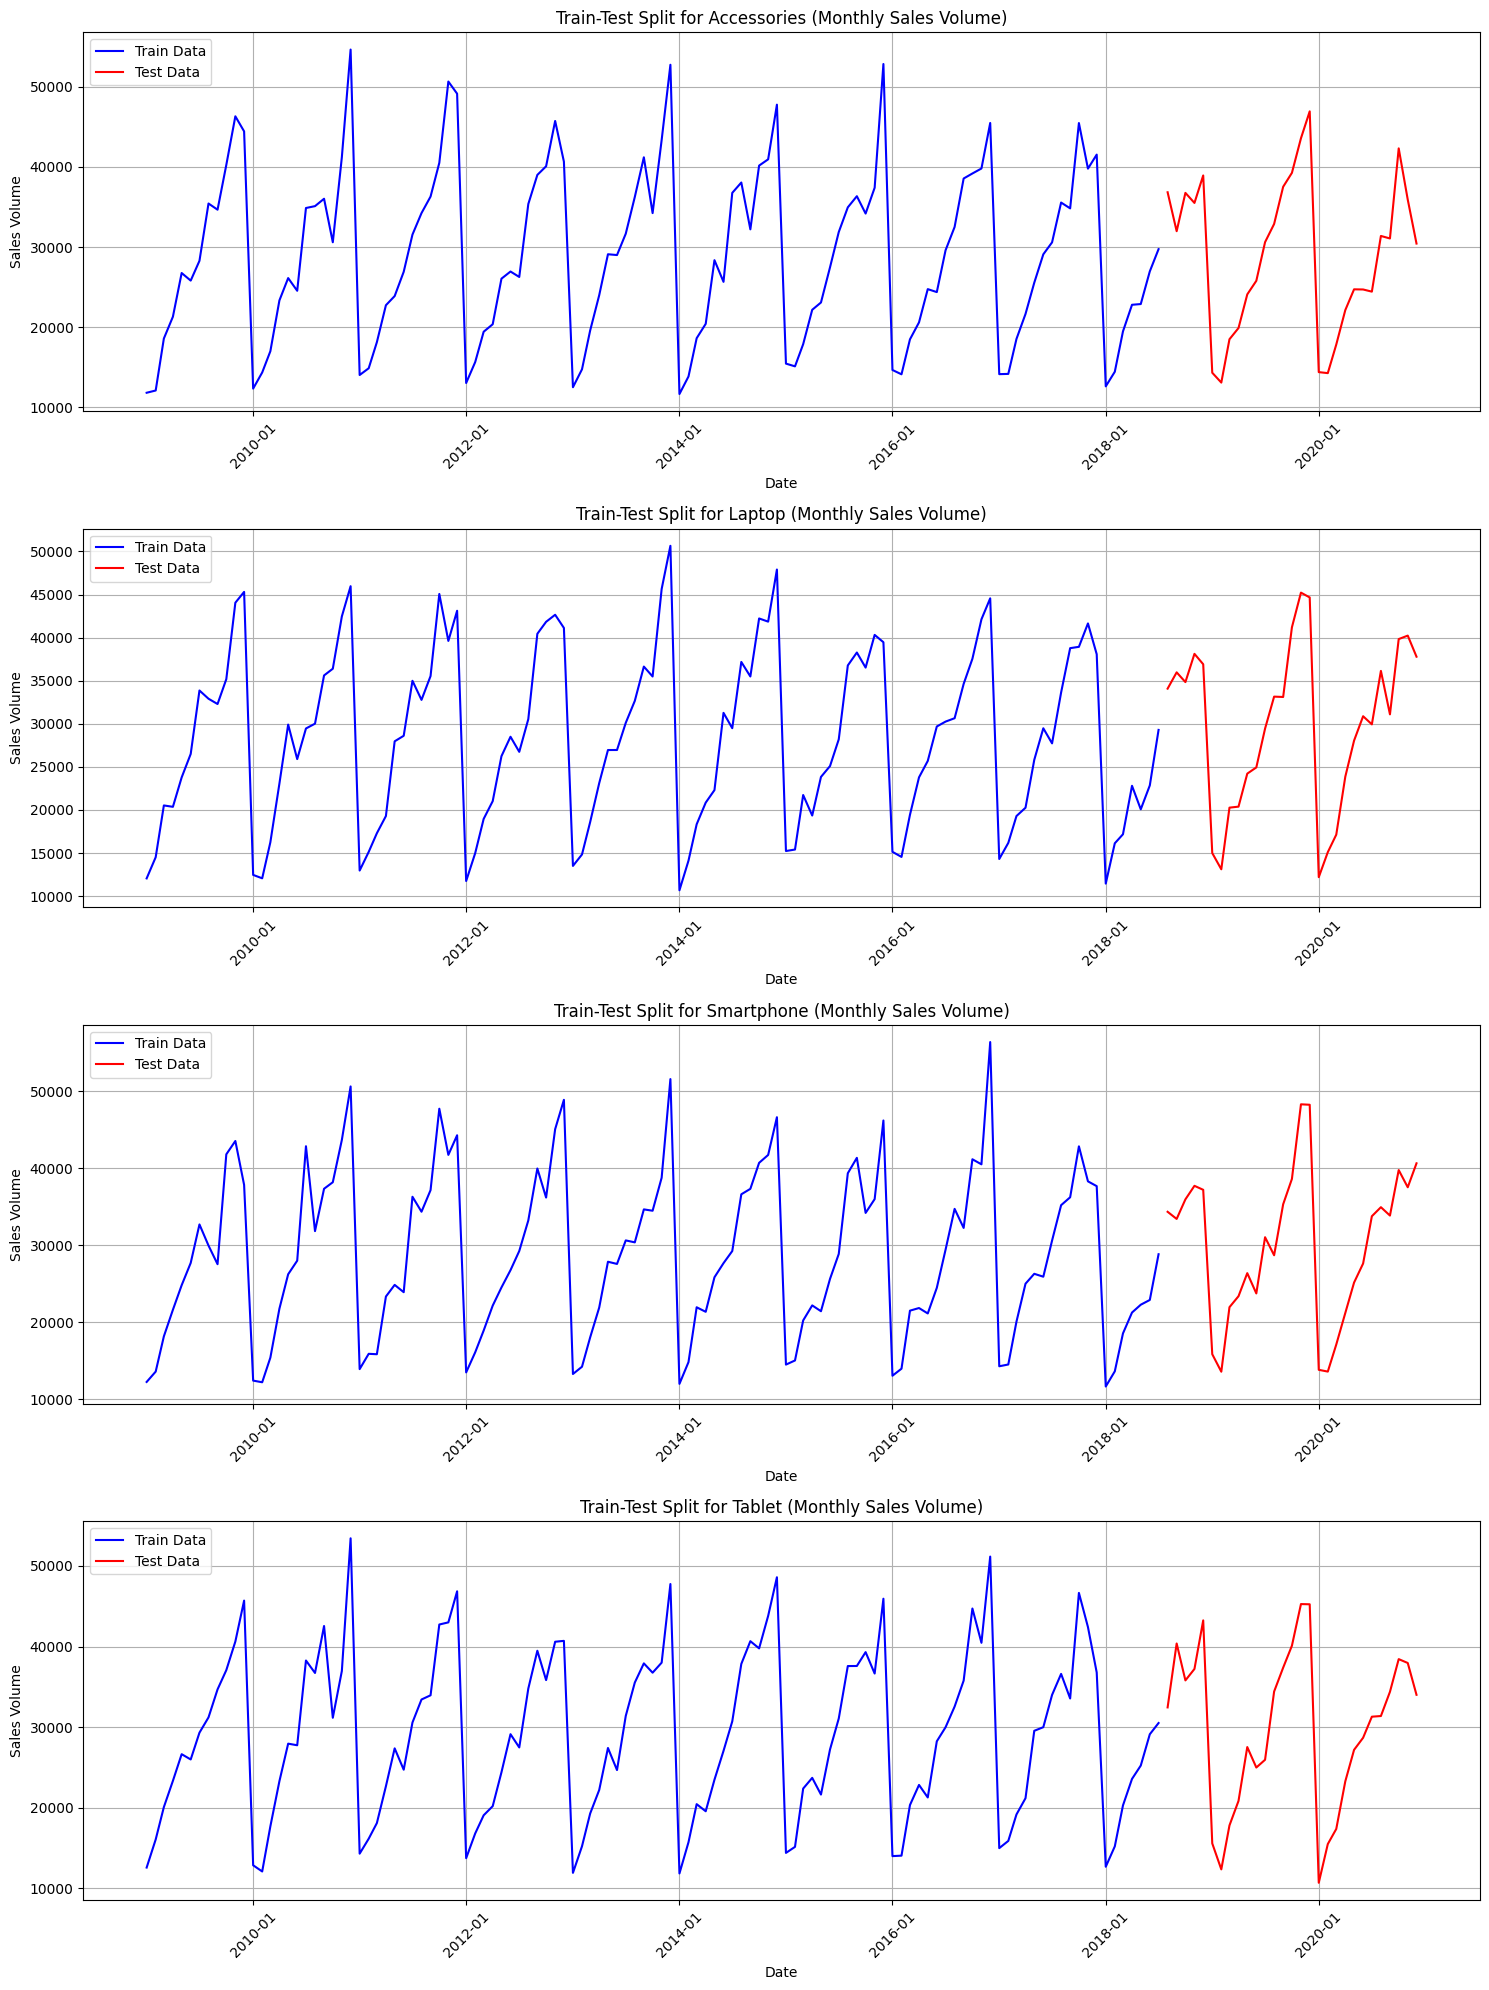

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

train_data = dict()
test_data = dict()

# Loop through each product category
for cat in sales_by_month_category['Category'].unique():
    df_cat = sales_by_month_category[sales_by_month_category['Category'] == cat].copy()
    
    # Optional: Sort by index (Date), only if you're unsure
    df_cat = df_cat.sort_index()

    # Chronological train-test split (80% train, 20% test)
    split_index = int(len(df_cat) * 0.8)
    train_data[cat] = df_cat.iloc[:split_index]
    test_data[cat] = df_cat.iloc[split_index:]

# Visualisation of Train-Test Split
categories = sales_by_month_category['Category'].unique()

fig, ax = plt.subplots(len(categories), 1, figsize=(15, 5 * len(categories)))

# Ensure ax is iterable even for a single plot
if len(categories) == 1:
    ax = [ax]

for i, cat in enumerate(categories): 
    ax[i].plot(train_data[cat].index,
               train_data[cat]['Sales_Volume'],
               color='blue', label='Train Data')

    ax[i].plot(test_data[cat].index,
               test_data[cat]['Sales_Volume'],
               color='red', label='Test Data')

    ax[i].set_title(f'Train-Test Split for {cat} (Monthly Sales Volume)')
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Sales Volume')
    ax[i].legend(loc='upper left')
    ax[i].grid(True)

    # ✅ Format the x-axis to show readable dates
    ax[i].xaxis.set_major_locator(mdates.AutoDateLocator())
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Modeling**

- ARIMA,
- Prophet,
- RandomForestRegressor.

For evaluation, we will be using:
- Mean Absolute Error (MAE),
- Root Mean Square Error (RMSE),
- Mean Absolute Percentage Error (MAPE)
- R² Score (Coefficient of Determination)

**Forecasting with ARIMA**

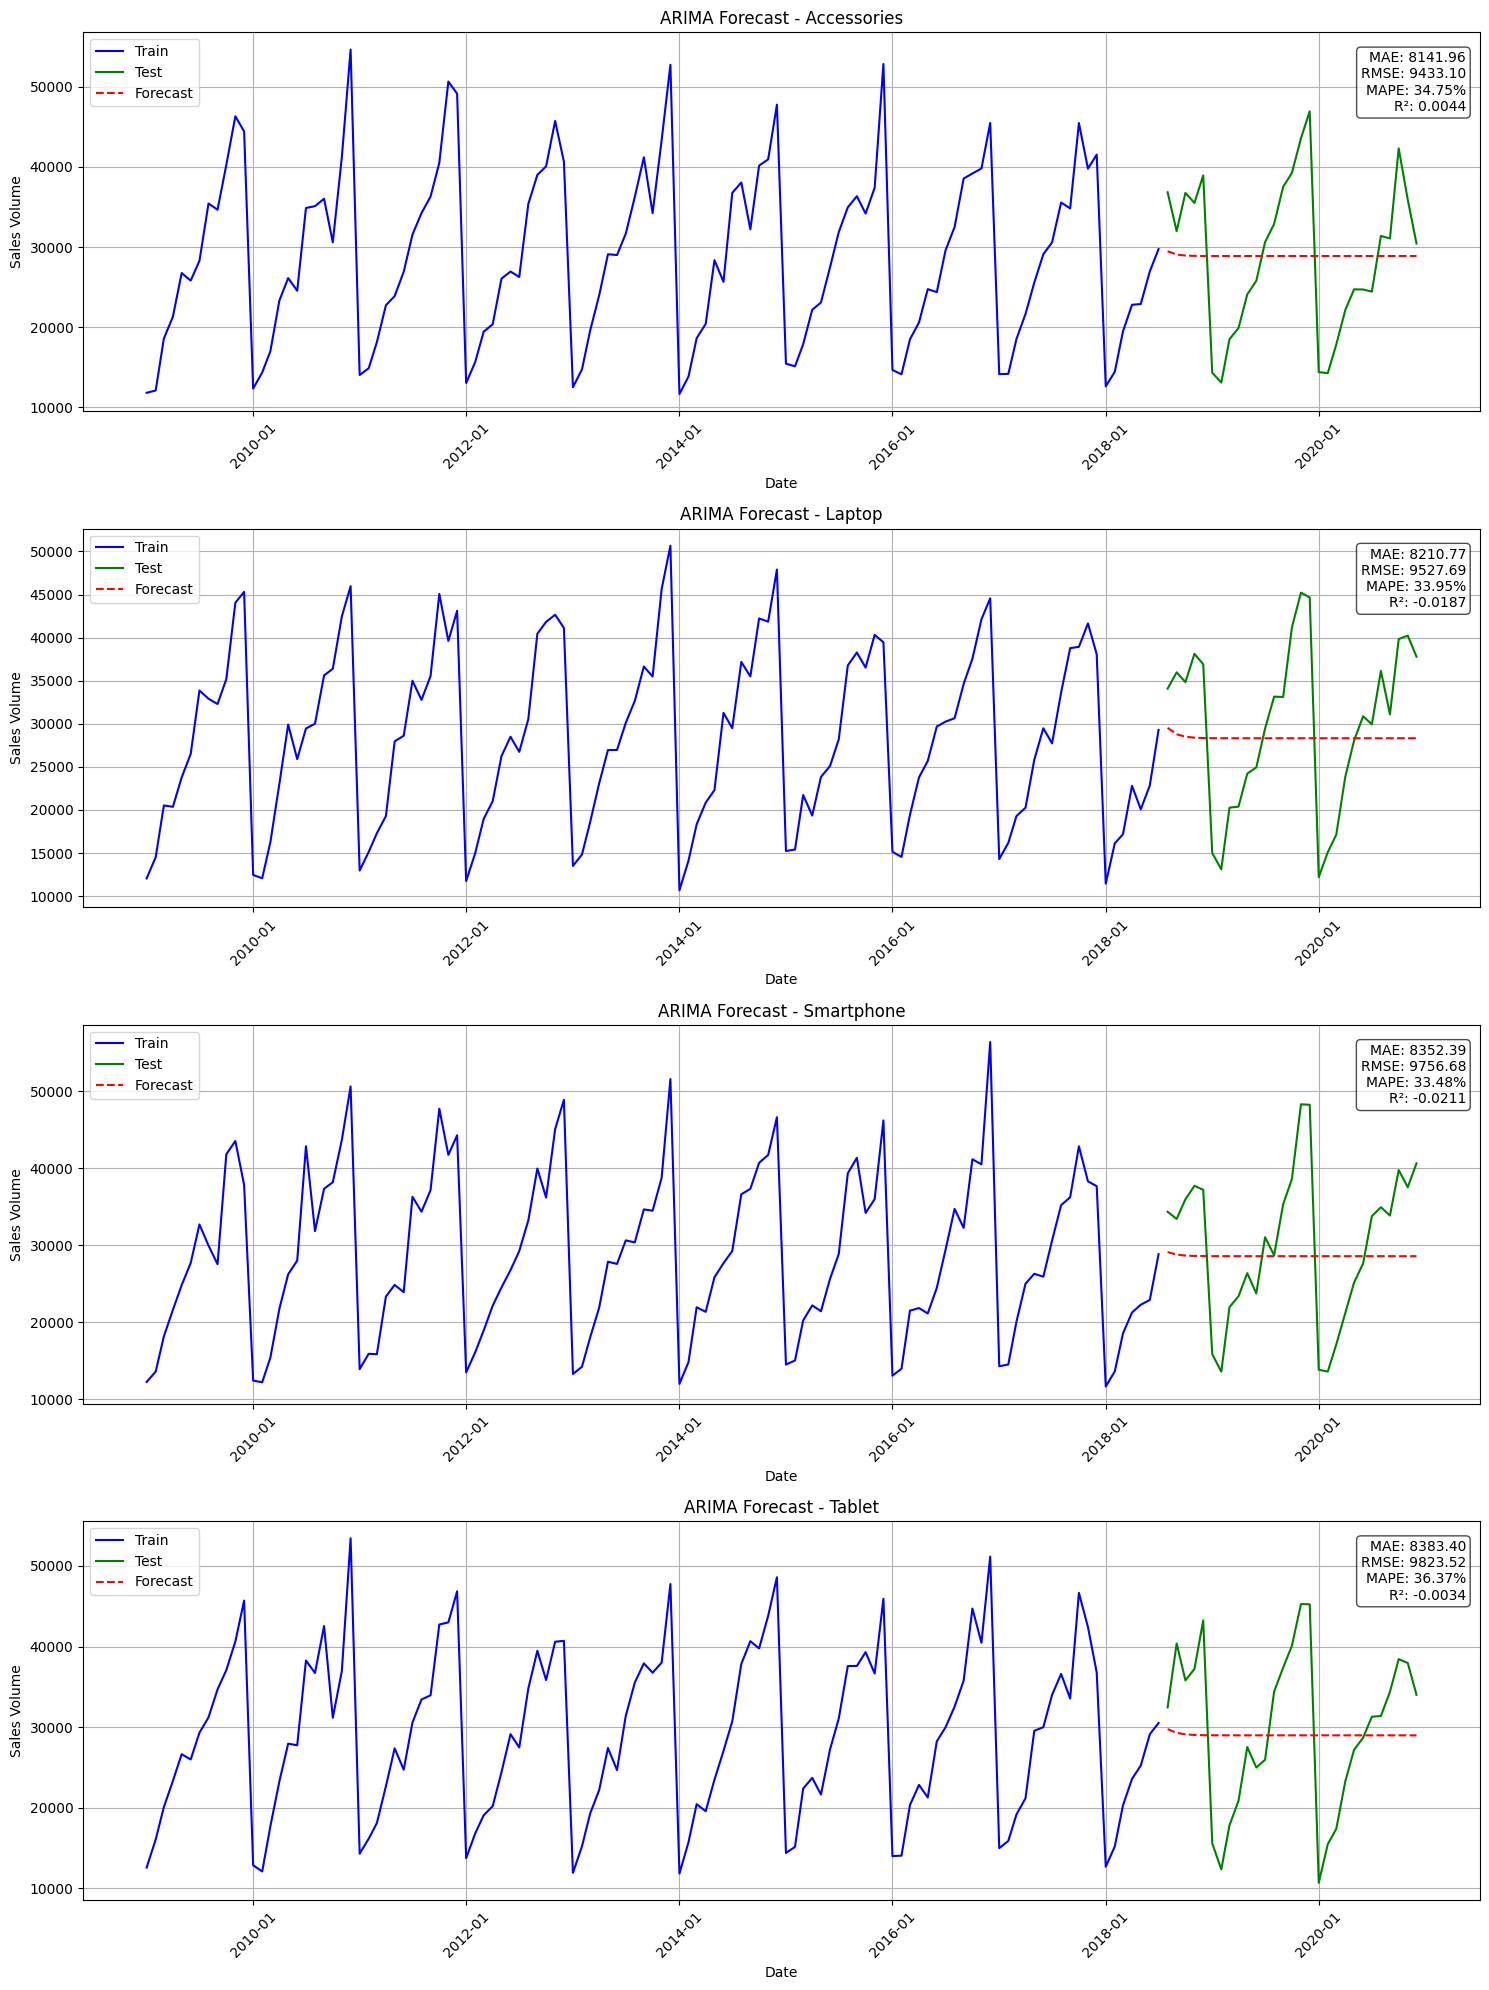


📊 Average Evaluation Metrics Across All Categories
Average MAE: 8272.13
Average RMSE: 9635.25
Average MAPE: 34.64%
Average R² Score: -0.0097


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import mlflow
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Set MLflow experiment only once per run/session (OK to keep)
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("Electrotech_Sales_Forecasting")

# Initialize accumulators for average metrics
mae, rmse, mape, r2 = 0, 0, 0, 0

# Dictionaries to store per-category results
arima_mae_scores = {}
arima_rmse_scores = {}
arima_mape_scores = {}
r2_scores = {}
arima_forecasts = {}

# Forecast visualization
categories = list(train_data.keys())
fig, ax = plt.subplots(len(categories), 1, figsize=(15, 5 * len(categories)))

# Ensure ax is iterable
if len(categories) == 1:
    ax = [ax]

# Iterate over each category
for i, category in enumerate(categories):
    y_train = train_data[category]['Sales_Volume']
    y_test = test_data[category]['Sales_Volume']

    # Fit ARIMA and forecast
    with mlflow.start_run(run_name=f"ARIMA_{category}"):
        model = ARIMA(y_train.values, order=(1, 0, 1))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(y_test))
        arima_forecasts[category] = forecast

        # Metrics
        category_mae = mean_absolute_error(y_test, forecast)
        category_rmse = np.sqrt(mean_squared_error(y_test, forecast))
        category_mape = mean_absolute_percentage_error(y_test, forecast) * 100
        category_r2 = r2_score(y_test, forecast)

        # Accumulate
        mae += category_mae
        rmse += category_rmse
        mape += category_mape
        r2 += category_r2

        # Store individual scores
        arima_mae_scores[category] = category_mae
        arima_rmse_scores[category] = category_rmse
        arima_mape_scores[category] = category_mape
        r2_scores[category] = category_r2

        # MLflow logs
        mlflow.log_param("ARIMA_order", (1, 0, 1))
        mlflow.log_metric("MAE", category_mae)
        mlflow.log_metric("RMSE", category_rmse)
        mlflow.log_metric("MAPE", category_mape)
        mlflow.log_metric("R2_Score", category_r2)

        # Save model
        model_filename = f"arima_model_{category}.joblib"
        joblib.dump(model_fit, model_filename)
        mlflow.log_artifact(model_filename)

        # === Main subplot figure ===
        ax[i].plot(y_train.index, y_train, label='Train', color='blue')
        ax[i].plot(y_test.index, y_test, label='Test', color='green')
        ax[i].plot(y_test.index, forecast, label='Forecast', color='red', linestyle='--')

        ax[i].set_title(f"ARIMA Forecast - {category}")
        ax[i].set_xlabel("Date")
        ax[i].set_ylabel("Sales Volume")
        ax[i].legend(loc='upper left')
        ax[i].grid(True)

        # Format x-axis
        ax[i].xaxis.set_major_locator(mdates.AutoDateLocator())
        ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax[i].tick_params(axis='x', rotation=45)

        # Annotate metrics in top-right
        ax[i].text(0.99, 0.95,
                   f"MAE: {category_mae:.2f}\nRMSE: {category_rmse:.2f}\nMAPE: {category_mape:.2f}%\nR²: {category_r2:.4f}",
                   transform=ax[i].transAxes,
                   verticalalignment='top',
                   horizontalalignment='right',
                   fontsize=10,
                   bbox=dict(boxstyle="round", facecolor='white', alpha=0.7))

        # === Save individual plot for MLflow ===
        fig_i, ax_i = plt.subplots(figsize=(12, 5))
        ax_i.plot(y_train.index, y_train, label="Train", color='blue')
        ax_i.plot(y_test.index, y_test, label="Test", color='green')
        ax_i.plot(y_test.index, forecast, label="Forecast", color='red', linestyle='--')
        ax_i.set_title(f"ARIMA Forecast - {category}")
        ax_i.set_xlabel("Date")
        ax_i.set_ylabel("Sales Volume")
        ax_i.legend(loc='upper left')
        ax_i.grid(True)
        ax_i.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax_i.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax_i.tick_params(axis='x', rotation=45)
        plt.tight_layout()

        # Save + log
        plot_file = f"arima_forecast_{category}.png"
        plt.savefig(plot_file)
        mlflow.log_artifact(plot_file)
        plt.close(fig_i)

# Show full subplot
plt.tight_layout()
plt.show()

# Average metrics 
n = len(categories)
print("\n📊 Average Evaluation Metrics Across All Categories")
print(f"Average MAE: {mae / n:.2f}")
print(f"Average RMSE: {rmse / n:.2f}")
print(f"Average MAPE: {mape / n:.2f}%")
print(f"Average R² Score: {r2 / n:.4f}")


**AUTO ARIMA**

In [35]:
from pmdarima import auto_arima

model = auto_arima(
    y_train,
    seasonal=False,        # Still plain ARIMA (no seasonal component)
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=0,                   # Confirmed stationary
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=False,         
    information_criterion='aic'
)

print(model.summary())
print("Best ARIMA order (p,d,q):", model.order)


 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2705.405, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2636.725, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=2617.983, Time=0.06 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=2610.559, Time=0.05 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=2614.820, Time=0.15 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=2619.795, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2457.297, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2455.852, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.41 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.33 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.73 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2456.523, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.36 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AI

**Forecast with Prophet Model

22:40:31 - cmdstanpy - INFO - Chain [1] start processing
22:40:32 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\.venv\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
22:40:33 - cmdstanpy - INFO - Chain [1] start processing
22:40:33 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\.venv\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
22:40:34 - cmdstanpy - INFO - Chain [1] start processing
22:40:34 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\.venv\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' i

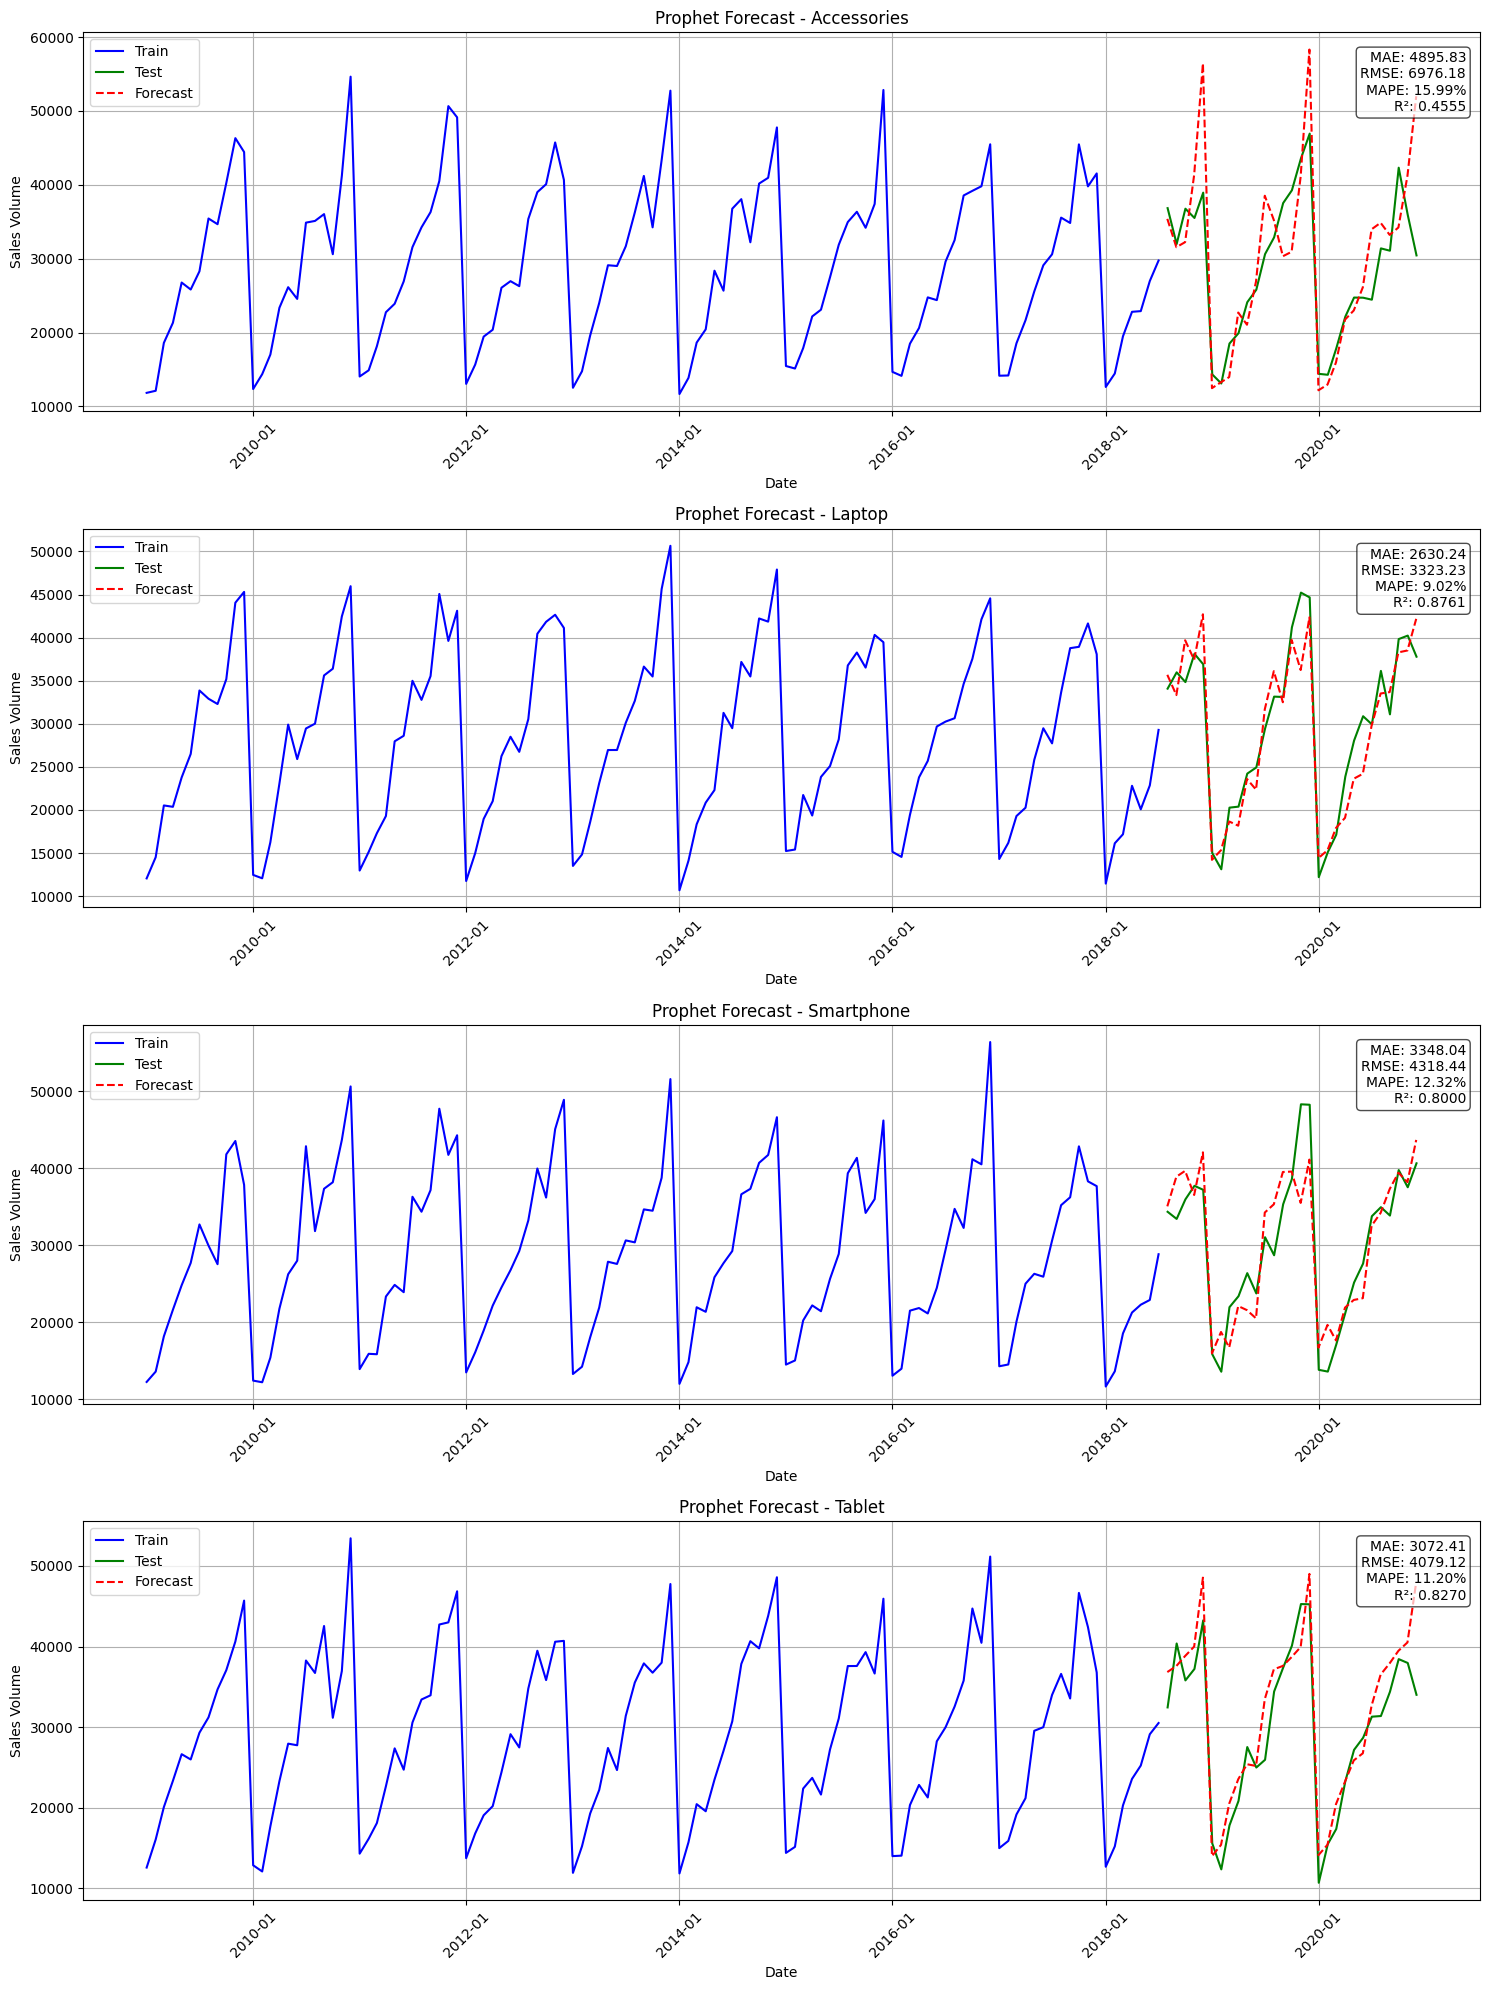


📊 Prophet - Average Evaluation Metrics
Average MAE: 3486.63
Average RMSE: 4674.24
Average MAPE: 12.13%
Average R² Score: 0.7396


In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
import mlflow
import joblib
import tempfile


# Metric accumulators
mae, rmse, mape, r2 = 0, 0, 0, 0

# Storage dictionaries
prophet_models = {}
prophet_forecasts = {}
prophet_mae_scores = {}
prophet_rmse_scores = {}
prophet_mape_scores = {}
prophet_r2_scores = {}

# Plot setup
categories = list(train_data.keys())
fig, ax = plt.subplots(len(categories), 1, figsize=(15, 5 * len(categories)))

if len(categories) == 1:
    ax = [ax]

# Prophet per category
for i, category in enumerate(categories):

    # Prepare train & test 
    train = train_data[category].copy().reset_index()
    test = test_data[category].copy().reset_index()

    train.rename(columns={'Date': 'ds', 'Sales_Volume': 'y'}, inplace=True)
    test.rename(columns={'Date': 'ds', 'Sales_Volume': 'y'}, inplace=True)

    with mlflow.start_run(run_name=f"Prophet_{category}"):

        # Fit Prophet 
        model = Prophet(
            yearly_seasonality=True,
            daily_seasonality=False
        )
        model.fit(train)
        prophet_models[category] = model

        # Forecast 
        future = model.make_future_dataframe(
            periods=len(test),
            freq='M'
        )
        forecast_all = model.predict(future)
        prophet_forecasts[category] = forecast_all

        # --- Extract test forecast ---
        test_forecast = forecast_all.tail(len(test)).copy()

        # METRICS 
        category_mae = mean_absolute_error(test['y'], test_forecast['yhat'])
        category_rmse = np.sqrt(mean_squared_error(test['y'], test_forecast['yhat']))
        category_mape = mean_absolute_percentage_error(test['y'], test_forecast['yhat']) * 100
        category_r2 = r2_score(test['y'], test_forecast['yhat'])

        # Accumulate
        mae += category_mae
        rmse += category_rmse
        mape += category_mape
        r2 += category_r2

        # Store per category
        prophet_mae_scores[category] = category_mae
        prophet_rmse_scores[category] = category_rmse
        prophet_mape_scores[category] = category_mape
        prophet_r2_scores[category] = category_r2

        # MLflow logging
        mlflow.log_params({
            "model": "Prophet",
            "yearly_seasonality": True,
            "daily_seasonality": False,
            "frequency": "Monthly"
        })

        mlflow.log_metrics({
            "MAE": category_mae,
            "RMSE": category_rmse,
            "MAPE": category_mape,
            "R2_Score": category_r2
        })

        # Save model safely
        with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as tmp:
            joblib.dump(model, tmp.name)
            mlflow.log_artifact(tmp.name, artifact_path=f"prophet_model_{category}")

        # MAIN SUBPLOT
        ax[i].plot(train['ds'], train['y'], label='Train', color='blue')
        ax[i].plot(test['ds'], test['y'], label='Test', color='green')
        ax[i].plot(
            test_forecast['ds'],
            test_forecast['yhat'],
            label='Forecast',
            color='red',
            linestyle='--'
        )

        ax[i].set_title(f"Prophet Forecast - {category}")
        ax[i].set_xlabel("Date")
        ax[i].set_ylabel("Sales Volume")
        ax[i].legend(loc='upper left')
        ax[i].grid(True)

        ax[i].xaxis.set_major_locator(mdates.AutoDateLocator())
        ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax[i].tick_params(axis='x', rotation=45)

        # Metrics box (top-right) 
        ax[i].text(
            0.99, 0.95,
            f"MAE: {category_mae:.2f}\n"
            f"RMSE: {category_rmse:.2f}\n"
            f"MAPE: {category_mape:.2f}%\n"
            f"R²: {category_r2:.4f}",
            transform=ax[i].transAxes,
            verticalalignment='top',
            horizontalalignment='right',
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor='white', alpha=0.7)
        )

        # SAVE INDIVIDUAL PLOT
        fig_ind, ax_ind = plt.subplots(figsize=(12, 5))
        ax_ind.plot(train['ds'], train['y'], label='Train', color='blue')
        ax_ind.plot(test['ds'], test['y'], label='Test', color='green')
        ax_ind.plot(
            test_forecast['ds'],
            test_forecast['yhat'],
            label='Forecast',
            color='red',
            linestyle='--'
        )

        ax_ind.set_title(f"Prophet Forecast – {category}")
        ax_ind.set_xlabel("Date")
        ax_ind.set_ylabel("Sales Volume")
        ax_ind.legend(loc='upper left')
        ax_ind.grid(True)

        ax_ind.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax_ind.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax_ind.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plot_file = f"prophet_forecast_{category}.png"
        plt.savefig(plot_file)
        mlflow.log_artifact(plot_file)
        plt.close(fig_ind)

# Show combined figure
plt.tight_layout()
plt.show()

# Average metrics
n = len(categories)
print("\n📊 Prophet - Average Evaluation Metrics")
print(f"Average MAE: {mae / n:.2f}")
print(f"Average RMSE: {rmse / n:.2f}")
print(f"Average MAPE: {mape / n:.2f}%")
print(f"Average R² Score: {r2 / n:.4f}")


**Forecast with Exponential Smoothing**

c:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\USER\Desktop\Projects\Data Science\Regression\Electrotech Forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe

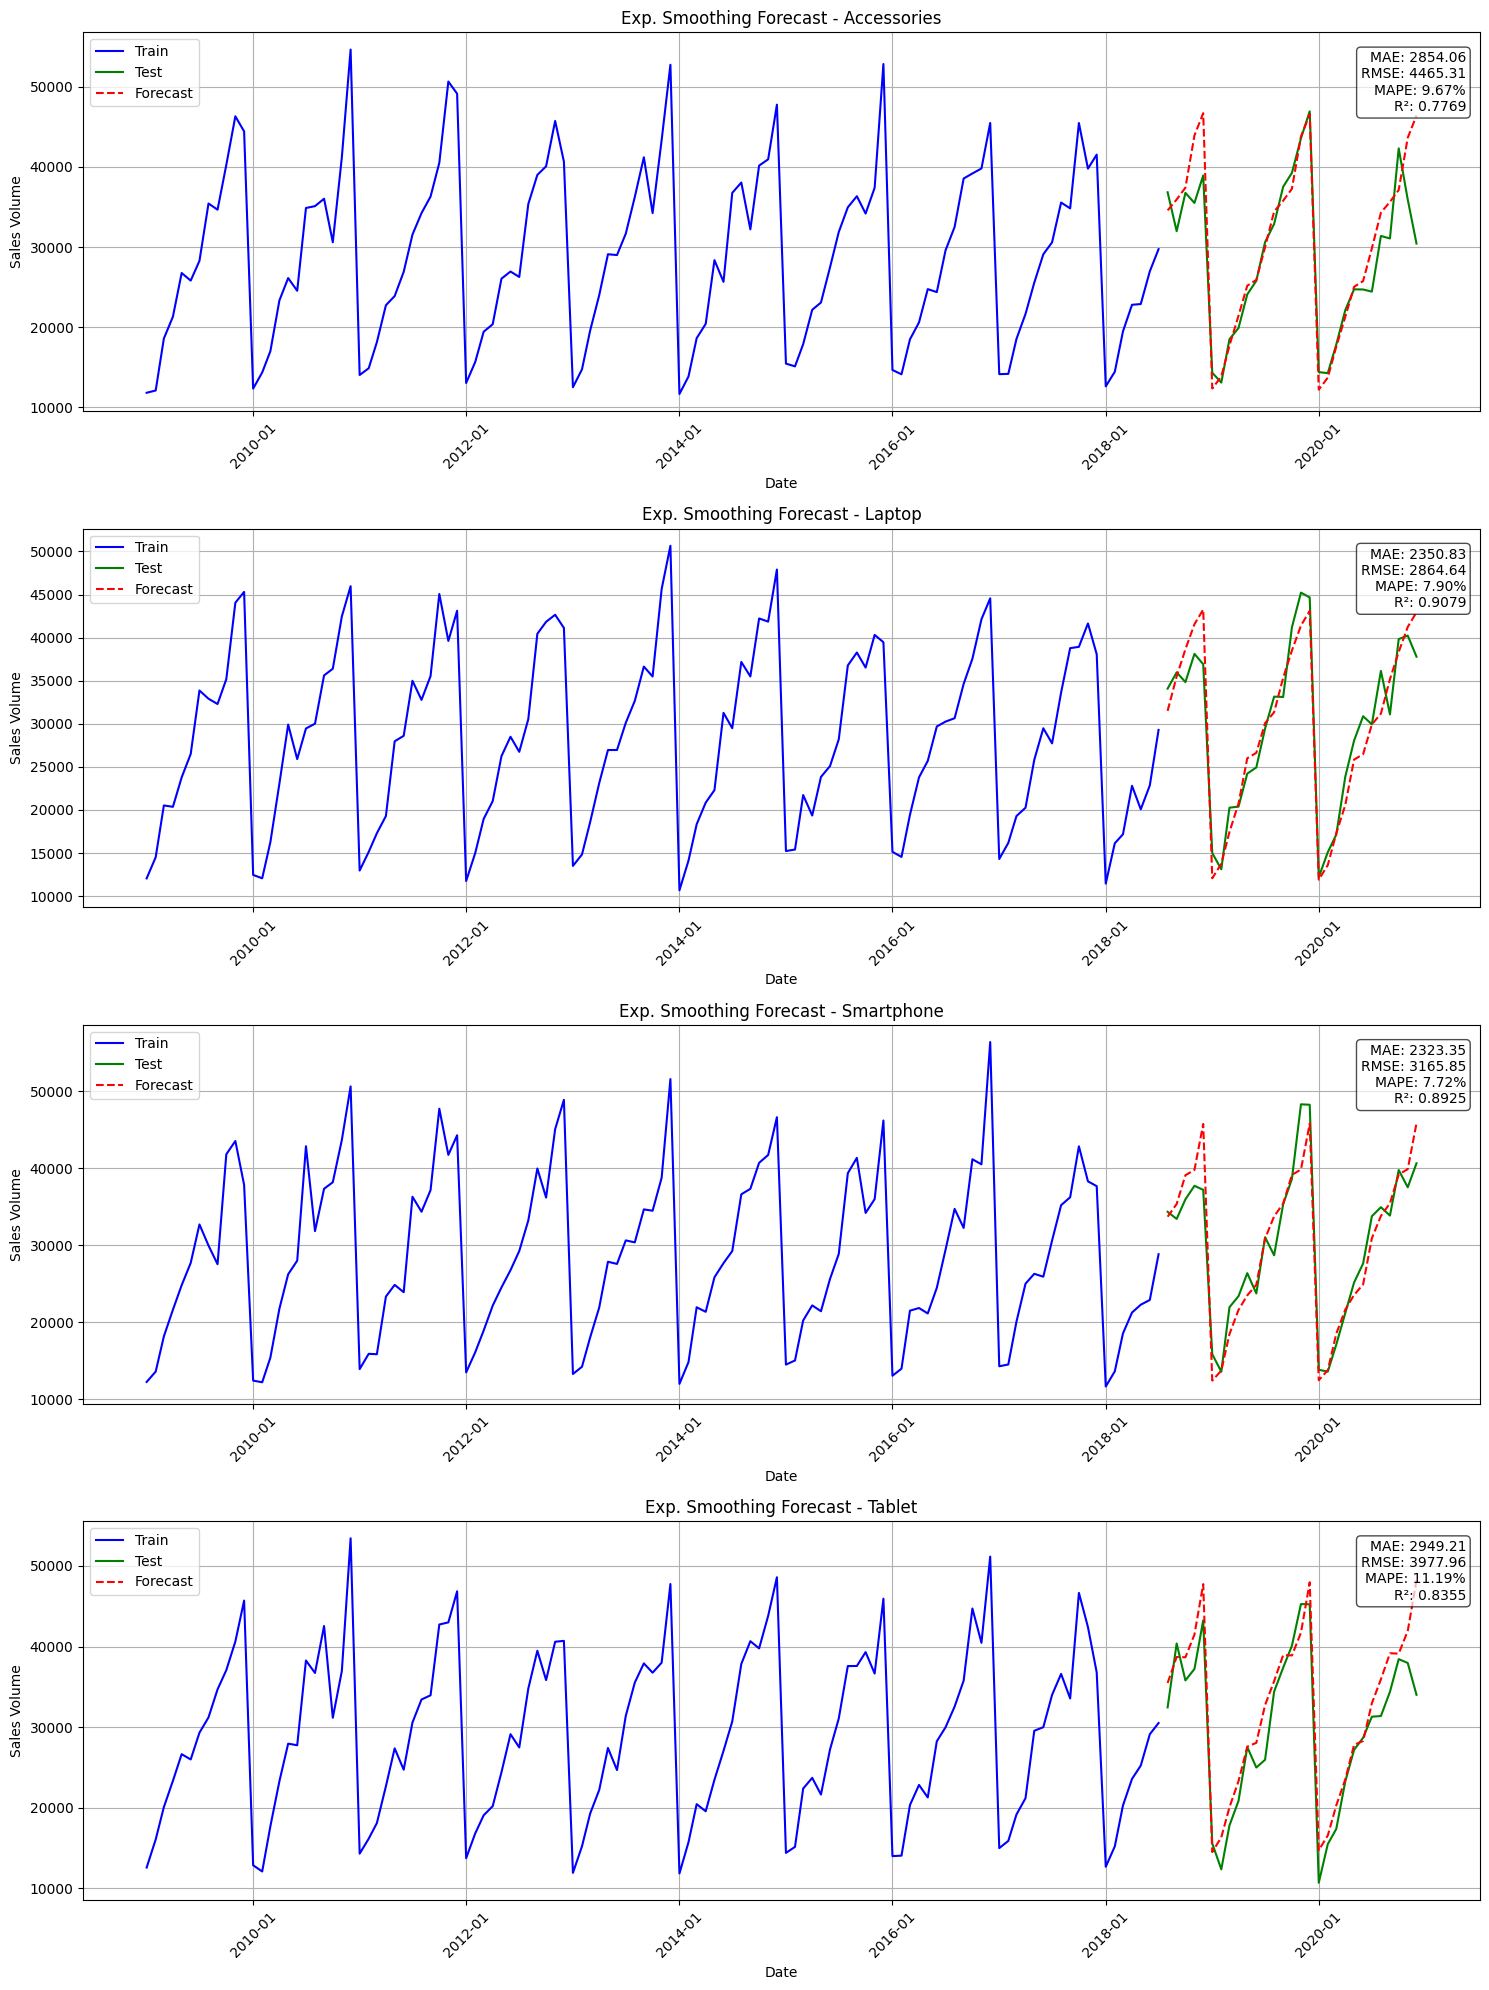


📊 Exponential Smoothing - Average Metrics:
Average MAE: 2619.36
Average RMSE: 3618.44
Average MAPE: 9.12%
Average R² Score: 0.8532


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import mlflow
import joblib
import tempfile

# Initialize accumulators
mae, rmse, mape, r2 = 0, 0, 0, 0

# Dictionaries to store results
exp_smoothing_models = {}
exp_smoothing_forecasts = {}
exp_mae_scores = {}
exp_rmse_scores = {}
exp_mape_scores = {}
exp_r2_scores = {}

# Plot setup
categories = list(train_data.keys())
fig, ax = plt.subplots(len(categories), 1, figsize=(15, 5 * len(categories)))
if len(categories) == 1:
    ax = [ax]

# Forecasting per category
for i, category in enumerate(categories):
    train = train_data[category]['Sales_Volume']
    test = test_data[category]['Sales_Volume']

    # Ensure datetime index for proper plotting
    y_train = train.copy()
    y_test = test.copy()

    with mlflow.start_run(run_name=f"ExpSmoothing_{category}"):
        # Fit Exponential Smoothing model
        model = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=12)
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(y_test))
        exp_smoothing_models[category] = model_fit
        exp_smoothing_forecasts[category] = forecast

        # Evaluate
        category_mae = mean_absolute_error(y_test, forecast)
        category_rmse = np.sqrt(mean_squared_error(y_test, forecast))
        category_mape = mean_absolute_percentage_error(y_test, forecast) * 100
        category_r2 = r2_score(y_test, forecast)

        # Accumulate
        mae += category_mae
        rmse += category_rmse
        mape += category_mape
        r2 += category_r2

        # Store per-category scores
        exp_mae_scores[category] = category_mae
        exp_rmse_scores[category] = category_rmse
        exp_mape_scores[category] = category_mape
        exp_r2_scores[category] = category_r2

        # Log to MLflow
        mlflow.log_params({
            "model": "ExponentialSmoothing",
            "trend": "add",
            "seasonal": "add",
            "seasonal_periods": 12
        })

        mlflow.log_metrics({
            "MAE": category_mae,
            "RMSE": category_rmse,
            "MAPE": category_mape,
            "R2_Score": category_r2
        })

        # Save model
        with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as tmp:
            joblib.dump(model_fit, tmp.name)
            mlflow.log_artifact(tmp.name, artifact_path=f"exp_smoothing_model_{category}")

        # === Plot ===
        ax[i].plot(y_train.index, y_train, label="Train", color="blue")
        ax[i].plot(y_test.index, y_test, label="Test", color="green")
        ax[i].plot(y_test.index, forecast, label="Forecast", color="red", linestyle='--')

        ax[i].set_title(f"Exp. Smoothing Forecast - {category}")
        ax[i].set_xlabel("Date")
        ax[i].set_ylabel("Sales Volume")
        ax[i].legend(loc='upper left')
        ax[i].grid(True)
        ax[i].xaxis.set_major_locator(mdates.AutoDateLocator())
        ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax[i].tick_params(axis='x', rotation=45)

        # Annotate metrics
        ax[i].text(0.99, 0.95,
                   f"MAE: {category_mae:.2f}\nRMSE: {category_rmse:.2f}\nMAPE: {category_mape:.2f}%\nR²: {category_r2:.4f}",
                   transform=ax[i].transAxes,
                   verticalalignment='top',
                   horizontalalignment='right',
                   fontsize=10,
                   bbox=dict(boxstyle="round", facecolor='white', alpha=0.7))

        # Save and log individual plot
        fig_ind, ax_ind = plt.subplots(figsize=(12, 5))
        ax_ind.plot(y_train.index, y_train, label="Train", color="blue")
        ax_ind.plot(y_test.index, y_test, label="Test", color="green")
        ax_ind.plot(y_test.index, forecast, label="Forecast", color="red", linestyle='--')
        ax_ind.set_title(f"Exp. Smoothing Forecast - {category}")
        ax_ind.set_xlabel("Date")
        ax_ind.set_ylabel("Sales Volume")
        ax_ind.legend(loc='upper left')
        ax_ind.grid(True)
        ax_ind.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax_ind.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax_ind.tick_params(axis='x', rotation=45)
        plt.tight_layout()

        plot_file = f"exp_smoothing_forecast_{category}.png"
        plt.savefig(plot_file)
        mlflow.log_artifact(plot_file)
        plt.close(fig_ind)

# Final combined plot
plt.tight_layout()
plt.show()

# === Print average metrics ===
n = len(categories)
print(f"\n📊 Exponential Smoothing - Average Metrics:")
print(f"Average MAE: {mae / n:.2f}")
print(f"Average RMSE: {rmse / n:.2f}")
print(f"Average MAPE: {mape / n:.2f}%")
print(f"Average R² Score: {r2 / n:.4f}")


**Forecast with Random Forest**

- Random Forest is feature-driven and it is unlike time series models like ARIMA/Prophet which learn only from the past values of the series. 

- Hence, the needs for explicit feature engineering such as time-based variables (month, year, week) and domain-relevant exogenous features (price, season) to learn patterns like trends and seasonality

- These allow the model to simulate autoregressive behavior and capture external influences.

- Random Forest provides flexibility in modeling complex relationships by incorporating a variety of exogenous predictors such as price and seasonality. 

C:\Users\USER\AppData\Local\Temp\ipykernel_21060\3233762022.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(['Category', pd.Grouper(key='Date', freq='M')])


 Running RF for: Accessories
 Completed RF for: Accessories
 Running RF for: Laptop
 Completed RF for: Laptop
 Running RF for: Smartphone
 Completed RF for: Smartphone
 Running RF for: Tablet
 Completed RF for: Tablet


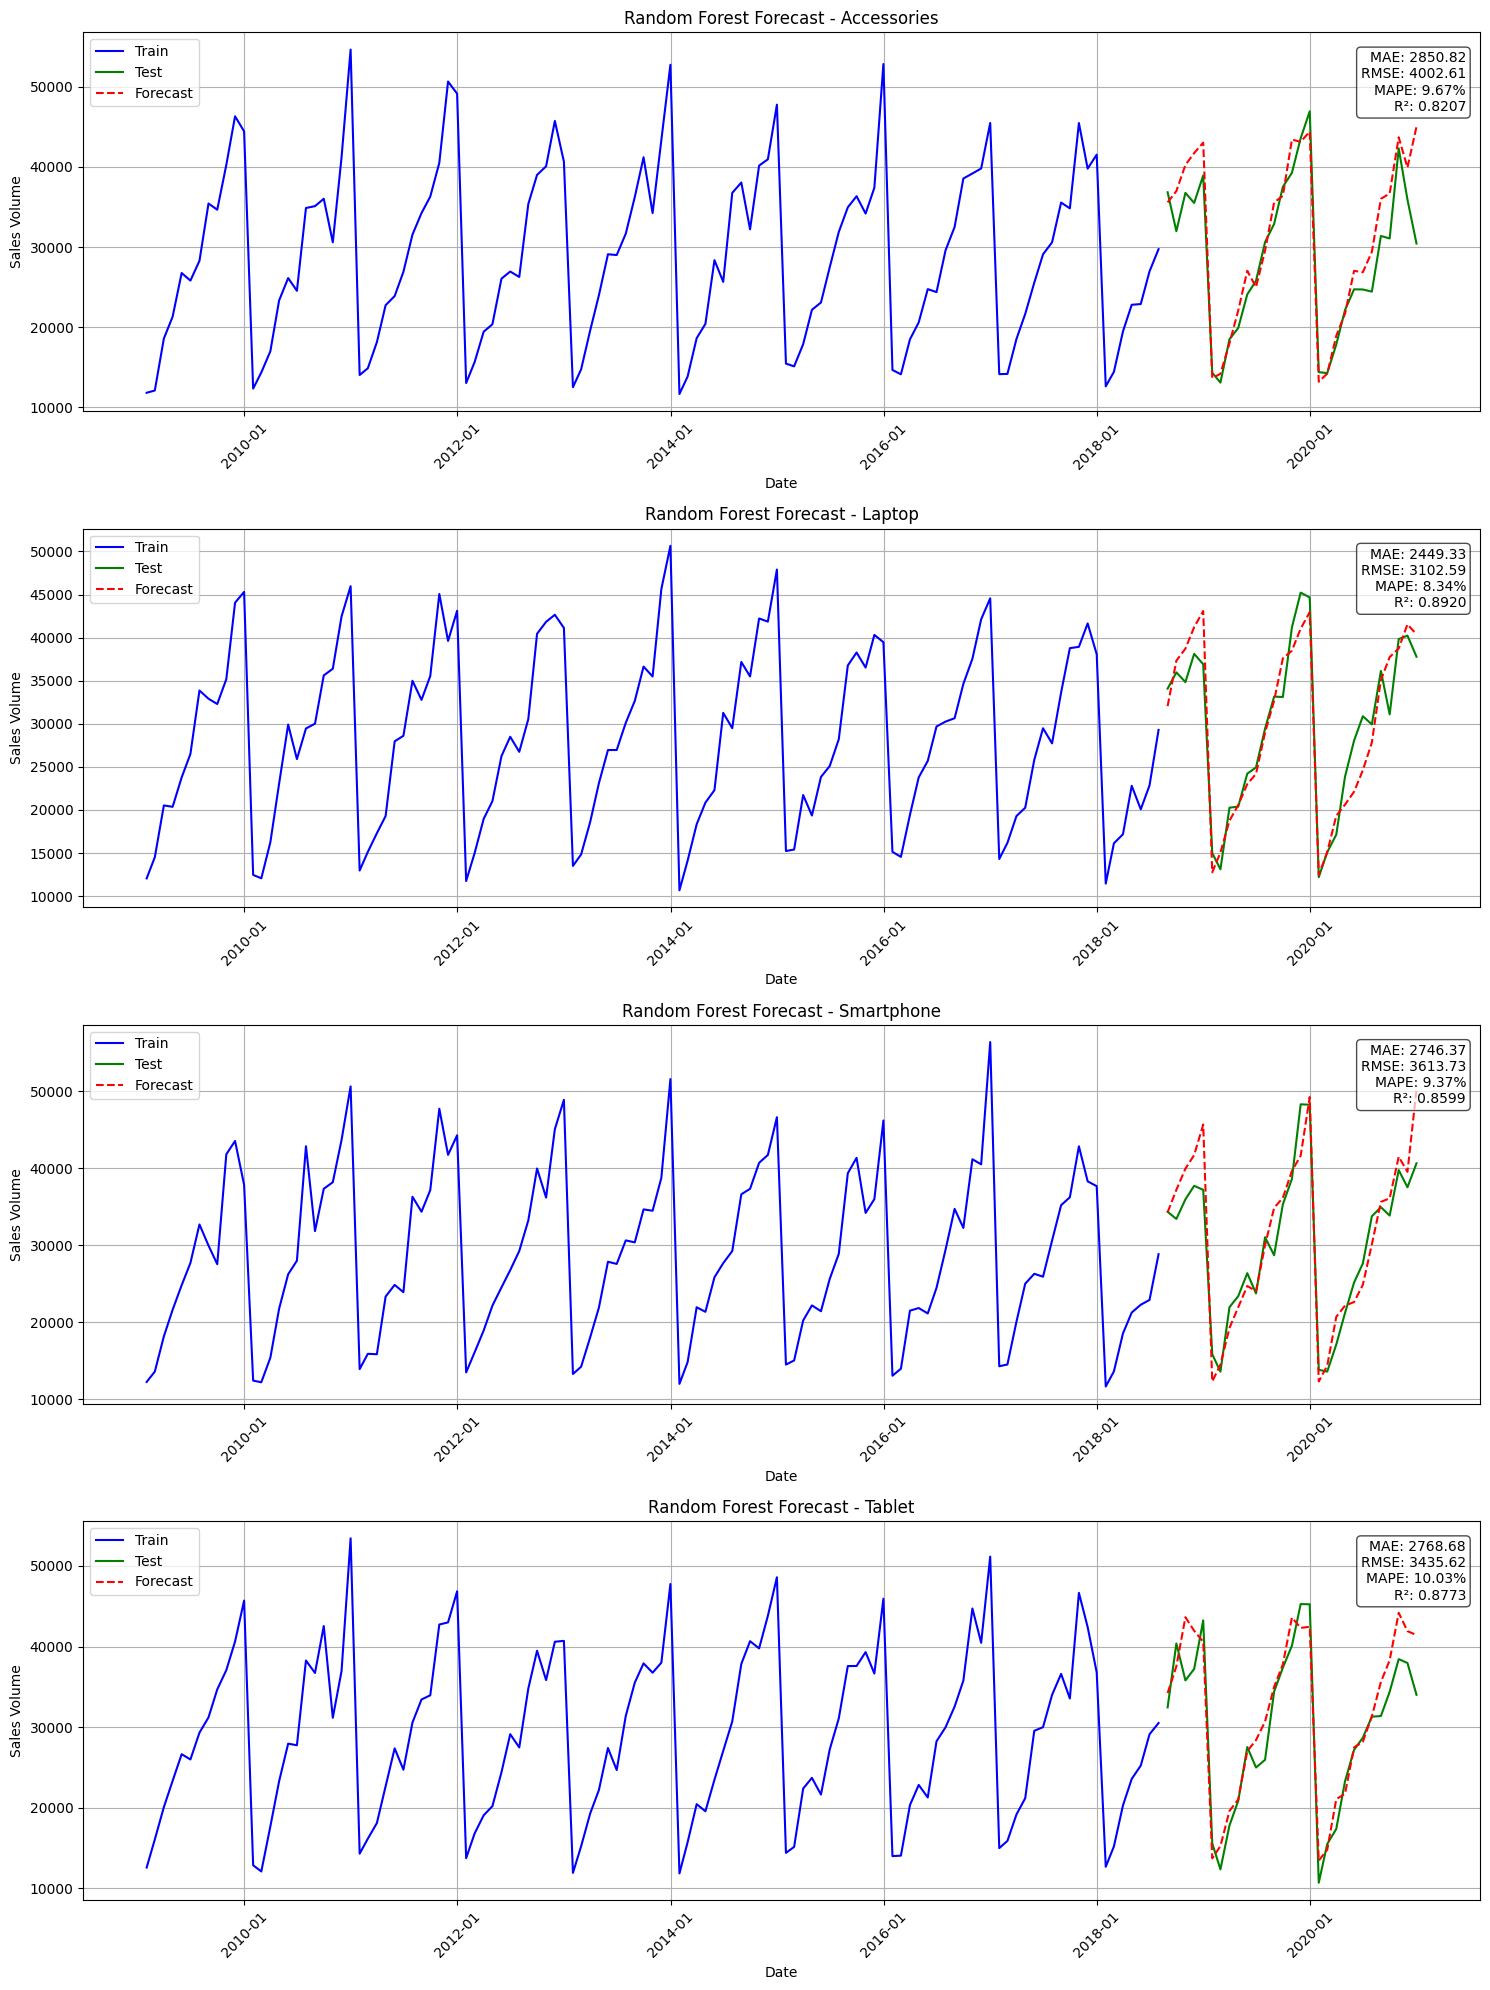


Average MAE: 2703.80
Average RMSE: 3538.64
Average MAPE: 9.35%
Average R² Score: 0.8625


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import mlflow
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split

# Preprocessing 
# Ensure Date is datetime
data['Date'] = pd.to_datetime(data['Date'])

# Keep necessary columns
df = data[['Date', 'Category', 'Sales_Volume', 'Price', 'Season']].copy()

# Resample monthly per category
df = (
    df.groupby(['Category', pd.Grouper(key='Date', freq='M')])
    .agg({
        'Sales_Volume': 'sum',
        'Price': 'mean',
        'Season': lambda x: x.mode()[0]  # Most common season that month
    })
    .reset_index()
)

# One-hot encode Season
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

# Create time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Store results
rf_mae_scores = {}
rf_rmse_scores = {}
rf_mape_scores = {}
rf_r2_scores = {}
rf_forecasts = {}

# Metrics accumulators
mae, rmse, mape, r2 = 0, 0, 0, 0

# Forecast plotting
categories = df['Category'].unique()
fig, ax = plt.subplots(len(categories), 1, figsize=(15, 5 * len(categories)))
if len(categories) == 1:
    ax = [ax]

for i, cat in enumerate(categories):
    df_cat = df[df['Category'] == cat].sort_values('Date').copy()

    # Features and target
    X = df_cat.drop(columns=['Sales_Volume', 'Category', 'Date'])
    y = df_cat['Sales_Volume']
    dates = df_cat['Date']

    # Chronological split (80/20)
    split_index = int(len(df_cat) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    date_train, date_test = dates.iloc[:split_index], dates.iloc[split_index:]

    # Skip if not enough data to train/test
    if len(X_train) == 0 or len(X_test) == 0:
        print(f" Skipping '{cat}': Not enough data to split.")
        continue

    print(f" Running RF for: {cat}")

    with mlflow.start_run(run_name=f"RF_{cat}"):
        # Fit model
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # Predict
        forecast = model.predict(X_test)
        rf_forecasts[cat] = forecast

        # Metrics
        category_mae = mean_absolute_error(y_test, forecast)
        category_rmse = np.sqrt(mean_squared_error(y_test, forecast))
        category_mape = mean_absolute_percentage_error(y_test, forecast) * 100
        category_r2 = r2_score(y_test, forecast)

        # Accumulate
        mae += category_mae
        rmse += category_rmse
        mape += category_mape
        r2 += category_r2

        # Store scores
        rf_mae_scores[cat] = category_mae
        rf_rmse_scores[cat] = category_rmse
        rf_mape_scores[cat] = category_mape
        rf_r2_scores[cat] = category_r2

        # MLflow logs
        mlflow.log_params({"model": "RandomForest", "n_estimators": 100})
        mlflow.log_metrics({
            "MAE": category_mae,
            "RMSE": category_rmse,
            "MAPE": category_mape,
            "R2_Score": category_r2
        })

        # Save model
        model_path = f"rf_model_{cat}.joblib"
        joblib.dump(model, model_path)
        mlflow.log_artifact(model_path)

        # === Plot Forecast ===
        ax[i].plot(date_train, y_train, label="Train", color="blue")
        ax[i].plot(date_test, y_test, label="Test", color="green")
        ax[i].plot(date_test, forecast, label="Forecast", color="red", linestyle='--')

        ax[i].set_title(f"Random Forest Forecast - {cat}")
        ax[i].set_xlabel("Date")
        ax[i].set_ylabel("Sales Volume")
        ax[i].legend(loc='upper left')
        ax[i].grid(True)
        ax[i].xaxis.set_major_locator(mdates.AutoDateLocator())
        ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax[i].tick_params(axis='x', rotation=45)

        # Annotate metrics
        ax[i].text(0.99, 0.95,
                   f"MAE: {category_mae:.2f}\nRMSE: {category_rmse:.2f}\nMAPE: {category_mape:.2f}%\nR²: {category_r2:.4f}",
                   transform=ax[i].transAxes,
                   verticalalignment='top',
                   horizontalalignment='right',
                   fontsize=10,
                   bbox=dict(boxstyle="round", facecolor='white', alpha=0.7))

        # Save plot
        fig_ind = plt.figure(figsize=(12, 5))
        plt.plot(date_train, y_train, label="Train", color="blue")
        plt.plot(date_test, y_test, label="Test", color="green")
        plt.plot(date_test, forecast, label="Forecast", color="red", linestyle='--')
        plt.title(f"RF Forecast - {cat}")
        plt.xlabel("Date")
        plt.ylabel("Sales Volume")
        plt.legend(loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plot_file = f"rf_forecast_{cat}.png"
        plt.savefig(plot_file)
        mlflow.log_artifact(plot_file)
        plt.close(fig_ind)

    print(f" Completed RF for: {cat}")
    
# Final layout
plt.tight_layout()
plt.show()

# Average metrics
n = len(categories)
print(f"\nAverage MAE: {mae/n:.2f}")
print(f"Average RMSE: {rmse/n:.2f}")
print(f"Average MAPE: {mape/n:.2f}%")
print(f"Average R² Score: {r2/n:.4f}")


**Recommendation** 

In [60]:
import numpy as np
import pandas as pd

# Add average scores to each model's dictionary 
# ARIMA
arima_mae_scores['--Average--'] = np.mean(list(arima_mae_scores.values()))
arima_rmse_scores['--Average--'] = np.mean(list(arima_rmse_scores.values()))
arima_mape_scores['--Average--'] = np.mean(list(arima_mape_scores.values()))
r2_scores['--Average--'] = np.mean(list(r2_scores.values()))

# Prophet
prophet_mae_scores['--Average--'] = np.mean(list(prophet_mae_scores.values()))
prophet_rmse_scores['--Average--'] = np.mean(list(prophet_rmse_scores.values()))
prophet_mape_scores['--Average--'] = np.mean(list(prophet_mape_scores.values()))
prophet_r2_scores['--Average--'] = np.mean(list(prophet_r2_scores.values()))

# Exponential Smoothing
exp_mae_scores['--Average--'] = np.mean(list(exp_mae_scores.values()))
exp_rmse_scores['--Average--'] = np.mean(list(exp_rmse_scores.values()))
exp_mape_scores['--Average--'] = np.mean(list(exp_mape_scores.values()))
exp_r2_scores['--Average--'] = np.mean(list(exp_r2_scores.values()))

# Random Forest
rf_mae_scores['--Average--'] = np.mean(list(rf_mae_scores.values()))
rf_rmse_scores['--Average--'] = np.mean(list(rf_rmse_scores.values()))
rf_mape_scores['--Average--'] = np.mean(list(rf_mape_scores.values()))
rf_r2_scores['--Average--'] = np.mean(list(rf_r2_scores.values()))

# === Create Metric DataFrames ===
mae_df = pd.DataFrame({
    'ARIMA': arima_mae_scores,
    'Prophet': prophet_mae_scores,
    'ExpSmoothing': exp_mae_scores,
    'RandomForest': rf_mae_scores   
})

rmse_df = pd.DataFrame({
    'ARIMA': arima_rmse_scores,
    'Prophet': prophet_rmse_scores,
    'ExpSmoothing': exp_rmse_scores,
    'RandomForest': rf_rmse_scores   
})

mape_df = pd.DataFrame({
    'ARIMA': arima_mape_scores,
    'Prophet': prophet_mape_scores,
    'ExpSmoothing': exp_mape_scores,
    'RandomForest': rf_mape_scores
})

r2_df = pd.DataFrame({
    'ARIMA': r2_scores,
    'Prophet': prophet_r2_scores,
    'ExpSmoothing': exp_r2_scores,
    'RandomForest': rf_r2_scores
})

# === Display All Together ===
print("\n Mean Absolute Error (MAE):")
display(mae_df)

print("\n Root Mean Squared Error (RMSE):")
display(rmse_df)

print("\n Mean Absolute Percentage Error (MAPE):")
display(mape_df)

print("\n R² Score:")
display(r2_df)



 Mean Absolute Error (MAE):


,ARIMA,Prophet,ExpSmoothing,RandomForest
Accessories,8141.959156,4895.828300,2854.057130,2850.815172
Laptop,8210.772670,2630.243027,2350.831403,2449.333448
Smartphone,8352.394678,3348.038479,2323.351523,2746.373448
Tablet,8383.395800,3072.413416,2949.208342,2768.681034
--Average--,8272.130576,3486.630805,2619.362099,2703.800776



 Root Mean Squared Error (RMSE):


,ARIMA,Prophet,ExpSmoothing,RandomForest
Accessories,9433.099978,6976.178247,4465.307119,4002.605890
Laptop,9527.688474,3323.226870,2864.637613,3102.591409
Smartphone,9756.675420,4318.437528,3165.846263,3613.734347
Tablet,9823.517622,4079.120666,3977.957904,3435.622042
--Average--,9635.245374,4674.240828,3618.437225,3538.638422



 Mean Absolute Percentage Error (MAPE):


,ARIMA,Prophet,ExpSmoothing,RandomForest
Accessories,34.748654,15.988948,9.667115,9.673639
Laptop,33.946437,9.023666,7.895582,8.339852
Smartphone,33.476029,12.318358,7.715636,9.372202
Tablet,36.373111,11.200266,11.190197,10.031751
--Average--,34.636058,12.132810,9.117132,9.354361



 R² Score:


,ARIMA,Prophet,ExpSmoothing,RandomForest
Accessories,0.004353,0.455458,0.776900,0.820741
Laptop,-0.018732,0.876062,0.907907,0.891973
Smartphone,-0.021081,0.799963,0.892493,0.859922
Tablet,-0.003372,0.826994,0.835469,0.877273
--Average--,-0.009708,0.739619,0.853192,0.862477


**Conclusion**

Random Model is the first choice because of its better overall model fit and ability to handle complexity. It also slightly edges ahead most espeically in RMSE and R². 

Exponential Smoothing model is the second choice because of its explainability, simplicity, and high absolute accuracy (e.g. MAE, MAPE)

Since the project is production-ready pipeline, random forest is considered for its robustness, especially when more features are involved. 
